In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data

In [28]:
natgas_df = pd.read_csv("Nat_Gas.csv")

natgas_df["Dates"] = pd.to_datetime(natgas_df["Dates"])

print("\n")
print(natgas_df.head(5))
print("...")
print(natgas_df.tail(5))
print("\n")
print(natgas_df.dtypes)




       Dates  Prices
0 2020-10-31    10.1
1 2020-11-30    10.3
2 2020-12-31    11.0
3 2021-01-31    10.9
4 2021-02-28    10.9
...
        Dates  Prices
43 2024-05-31    11.4
44 2024-06-30    11.5
45 2024-07-31    11.6
46 2024-08-31    11.5
47 2024-09-30    11.8


Dates     datetime64[ns]
Prices           float64
dtype: object


C:\Users\Owner\AppData\Local\Temp\ipykernel_7144\765131614.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  natgas_df["Dates"] = pd.to_datetime(natgas_df["Dates"])


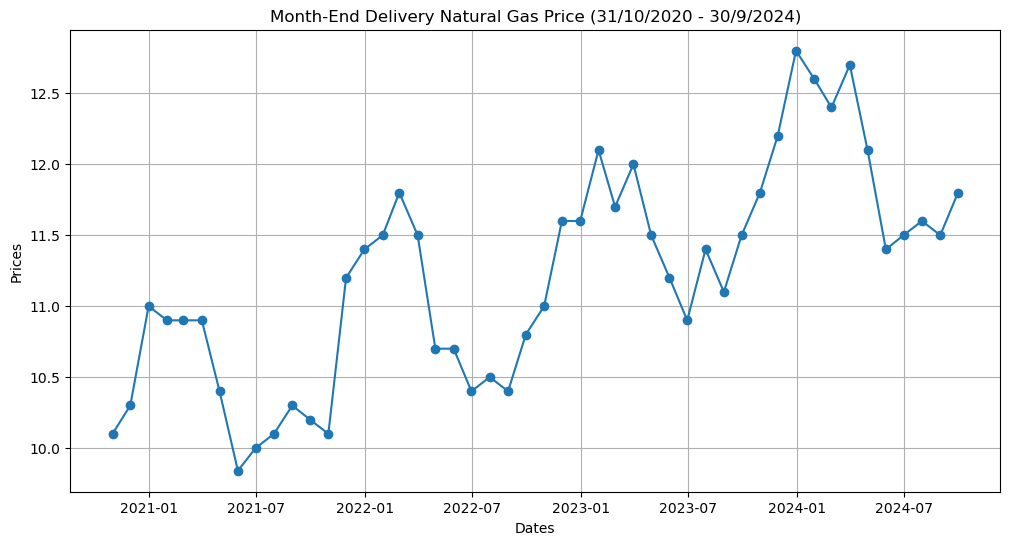

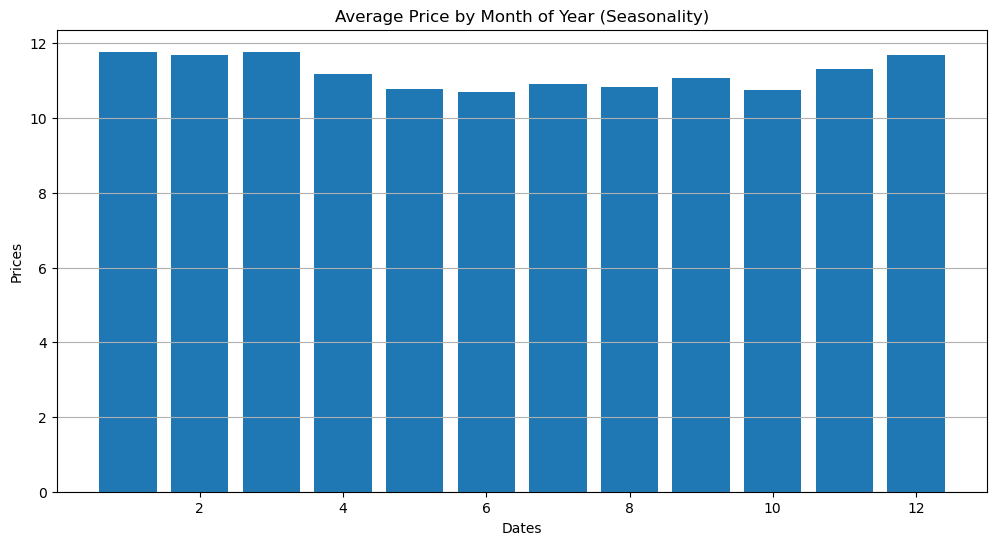

In [29]:
# Monthy Price Plot
plt.figure(figsize=(12,6))
plt.plot(natgas_df["Dates"], natgas_df["Prices"], marker="o")
plt.xlabel("Dates")
plt.ylabel("Prices")
plt.title("Month-End Delivery Natural Gas Price (31/10/2020 - 30/9/2024)")
plt.grid(True)
plt.show()

# Average Price By Month (Seasonality)
natgas_df["Month"] = natgas_df["Dates"].dt.month
month_avg = natgas_df.groupby("Month")["Prices"].mean()

plt.figure(figsize=(12,6))
plt.bar(month_avg.index, month_avg.values)
plt.xlabel("Dates")
plt.ylabel("Prices")
plt.title("Average Price by Month of Year (Seasonality)")
plt.grid(axis="y")
plt.show()

# Interpolate

In [31]:
price_vals = natgas_df["Prices"].values
date_int = natgas_df["Dates"].values.astype("datetime64[D]").astype(int)

def interpolate(query_date):
    q = pd.to_datetime(query_date)
    q_int = q.to_datetime64().astype("datetime64[D]").astype(int)
    return float(np.interp(q_int, date_int, price_vals))

print("Interpolation check(15-11-2022):", interpolate("2022-11-15"))

Interpolation check(15-11-2022): 11.3
